Человек касается dog (IoU=0.0037, overlap=0.0054, 141 px)


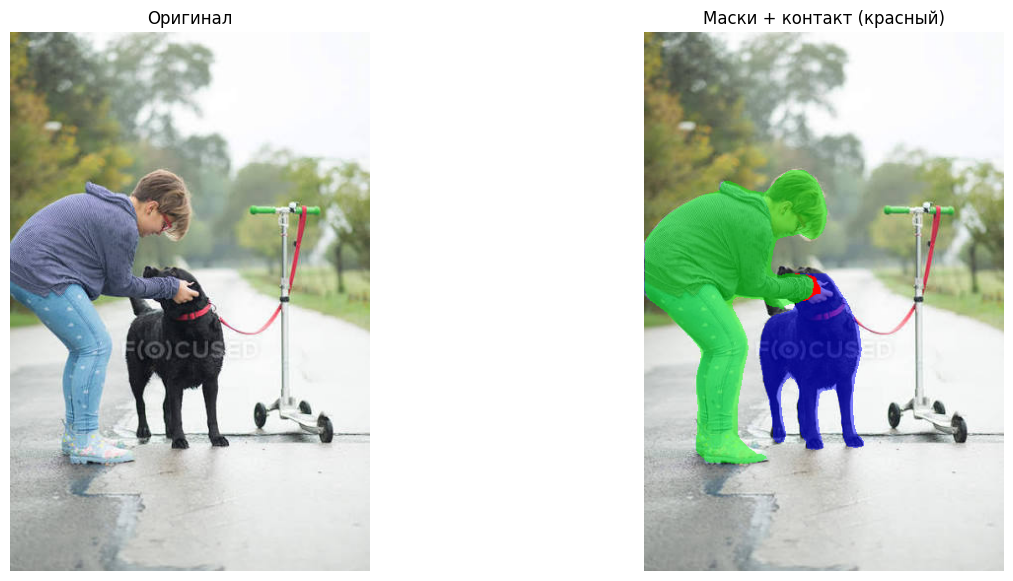

Человек касается giraffe (IoU=0.0021, overlap=0.0088, 125 px)


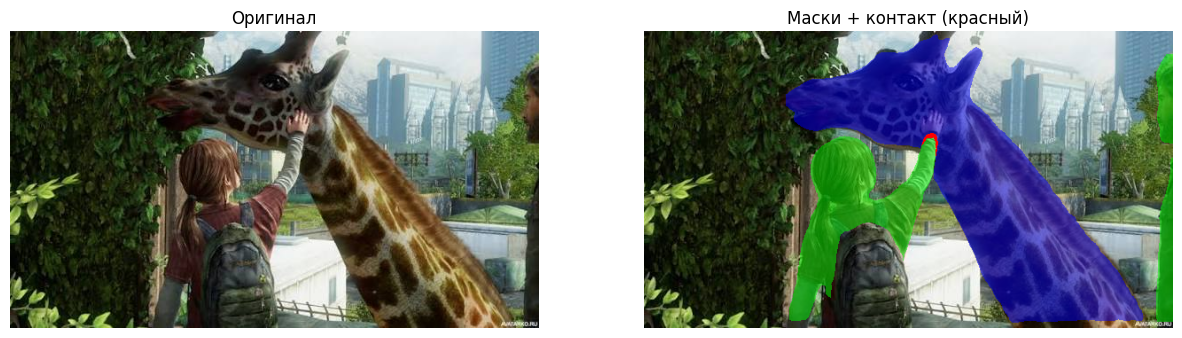

(array([[[ 23,  23,  23],
         [ 24,  24,  22],
         [ 23,  23,  21],
         ...,
         [110, 148, 171],
         [109, 147, 170],
         [109, 147, 170]],
 
        [[ 17,  17,  15],
         [ 14,  14,  12],
         [ 12,  13,   8],
         ...,
         [109, 147, 170],
         [109, 147, 170],
         [109, 147, 170]],
 
        [[ 15,  16,  11],
         [  9,  10,   4],
         [  6,   7,   1],
         ...,
         [109, 147, 170],
         [109, 147, 170],
         [109, 147, 170]],
 
        ...,
 
        [[  0,   6,   0],
         [  9,  15,   3],
         [ 11,  14,   3],
         ...,
         [115, 117, 116],
         [ 27,  29,  28],
         [ 16,  18,  17]],
 
        [[  0,   3,   0],
         [ 14,  22,  11],
         [ 15,  20,  13],
         ...,
         [ 13,  15,  14],
         [ 11,  13,  12],
         [ 38,  40,  39]],
 
        [[  0,   5,   0],
         [ 13,  20,  12],
         [ 14,  19,  13],
         ...,
         [ 27,  31,  30],
  

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")

PERSON_CLASS = 0
ANIMAL_CLASSES = {15: "cat", 16: "dog", 17: "horse", 18: "sheep",
                  19: "cow", 20: "elephant", 21: "bear", 22: "zebra", 23: "giraffe"}

def iou_mask(mask_a, mask_b):
    inter = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    return inter / union if union else 0.0

def overlap_ratio(mask_a, mask_b):
    inter = np.logical_and(mask_a, mask_b).sum()
    return inter / mask_a.sum() if mask_a.sum() else 0.0

def analyze_image(image_path,
                  iou_threshold=0.001,
                  ratio_threshold=0.005,
                  min_pixels=20):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    results = model.predict(img_rgb, verbose=False, retina_masks=True)[0]

    if results.masks is None:
        print("Объекты не найдены")
        return img_rgb, []

    masks = results.masks.data.cpu().numpy()
    classes = results.boxes.cls.cpu().numpy().astype(int)

    person_masks = [masks[i] for i, c in enumerate(classes) if c == PERSON_CLASS]
    animal_masks = [(masks[i], ANIMAL_CLASSES.get(classes[i], "animal"))
                    for i, c in enumerate(classes) if classes[i] in ANIMAL_CLASSES]

    overlay = img_rgb.copy()
    alerts = []
    contacts = []

    for pm in person_masks:
        overlay[pm > 0.5] = overlay[pm > 0.5] * 0.5 + np.array([0, 255, 0]) * 0.5
    for am, _ in animal_masks:
        overlay[am > 0.5] = overlay[am > 0.5] * 0.5 + np.array([0, 0, 255]) * 0.5

    for pm in person_masks:
        for am, animal_name in animal_masks:
            pm_bin = pm > 0.5
            am_bin = am > 0.5

            inter_mask = np.logical_and(pm_bin, am_bin)
            inter_pixels = int(inter_mask.sum())

            iou = iou_mask(pm_bin, am_bin)
            ratio = overlap_ratio(pm_bin, am_bin)

            if inter_pixels >= min_pixels and (iou > iou_threshold or ratio > ratio_threshold):
                overlay[inter_mask] = [255, 0, 0]   # красный

                contacts.append({
                    "animal": animal_name,
                    "iou": iou,
                    "ratio": ratio,
                    "pixels": inter_pixels,
                })
                alerts.append(
                    f"Человек касается {animal_name} "
                    f"(IoU={iou:.4f}, overlap={ratio:.4f}, {inter_pixels} px)"
                )

    if alerts:
        print("=" * 60)
        for a in alerts:
            print(a)
        print("=" * 60)
    else:
        print("Пересечений человек-животное не обнаружено")

    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    axes[0].imshow(img_rgb); axes[0].set_title("Оригинал"); axes[0].axis("off")
    axes[1].imshow(overlay)
    axes[1].set_title("Маски + контакт (красный)")
    axes[1].axis("off")
    plt.show()

    return overlay, contacts


# Запуск
analyze_image("petting.jpg")
analyze_image("petting2.jpg")

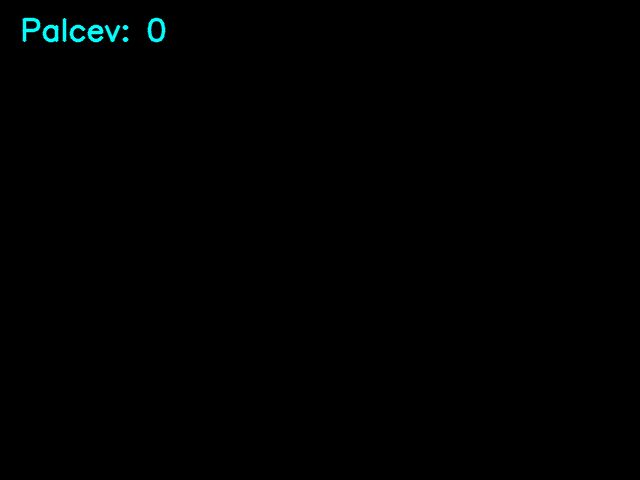

Кадр 1147 | Пальцев: 0


KeyboardInterrupt: 

In [9]:
import cv2
import mediapipe as mp
import numpy as np
import time
from IPython.display import display, Image, clear_output

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=2,
    min_detection_confidence=0.6,
    min_tracking_confidence=0.5
)

WRIST = 0
MIDDLE_MCP = 9

FINGER_JOINTS = {
    "thumb":  (2, 3, 4),
    "index":  (5, 6, 8),
    "middle": (9, 10, 12),
    "ring":   (13, 14, 16),
    "pinky":  (17, 18, 20),
}

FINGER_ORDER = ["thumb", "index", "middle", "ring", "pinky"]


def _dist(a, b):
    return float(np.hypot(a.x - b.x, a.y - b.y))


def finger_extension(lm, name):
    mcp_i, pip_i, tip_i = FINGER_JOINTS[name]
    mcp, pip, tip = lm[mcp_i], lm[pip_i], lm[tip_i]
    direct = _dist(mcp, tip)
    chain = _dist(mcp, pip) + _dist(pip, tip)
    return direct / chain if chain > 1e-6 else 0.0


def thumb_extended(lm):
    
    ext = finger_extension(lm, "thumb")
    palm = _dist(lm[WRIST], lm[MIDDLE_MCP]) or 1.0
    spread = _dist(lm[4], lm[5]) / palm

    return (ext > 0.85) or (spread > 0.7), ext, spread


def count_fingers(hand_landmarks, extend_threshold=0.9):
    lm = hand_landmarks.landmark
    fingers_up = []
    debug = {}

    is_up, ext, spread = thumb_extended(lm)
    debug["thumb"] = (ext, spread)
    if is_up:
        fingers_up.append("thumb")

    for name in FINGER_ORDER[1:]:
        ext = finger_extension(lm, name)
        debug[name] = (ext, None)
        if ext > extend_threshold:
            fingers_up.append(name)

    return fingers_up, len(fingers_up), debug


def run_hand_tracking(max_frames=300, target_fps=30, extend_threshold=0.9):
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Не удалось открыть камеру")
        return

    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

    frame_time = 1.0 / target_fps
    frame_count = 0

    try:
        while True:
            t0 = time.time()
            ret, frame = cap.read()
            if not ret:
                break

            frame = cv2.flip(frame, 1)
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            h, w = frame.shape[:2]

            results = hands.process(frame_rgb)

            canvas = np.zeros((h, w, 3), dtype=np.uint8)
            total_fingers = 0
            debug_lines = []

            if results.multi_hand_landmarks:
                for hand_landmarks, handedness in zip(
                    results.multi_hand_landmarks,
                    results.multi_handedness
                ):
                    hand_label = handedness.classification[0].label
                    lm = hand_landmarks.landmark

                    mp_drawing.draw_landmarks(
                        canvas, hand_landmarks, mp_hands.HAND_CONNECTIONS,
                        landmark_drawing_spec=mp_drawing.DrawingSpec(
                            color=(0, 255, 0), thickness=2, circle_radius=4
                        ),
                        connection_drawing_spec=mp_drawing.DrawingSpec(
                            color=(255, 0, 0), thickness=2
                        )
                    )

                    fingers, count, debug = count_fingers(
                        hand_landmarks, extend_threshold=extend_threshold
                    )
                    total_fingers += count

                    for name in FINGER_ORDER:
                        mcp_i, _, tip_i = FINGER_JOINTS[name]
                        mcp = lm[mcp_i]; tip = lm[tip_i]
                        ax, ay = int(mcp.x * w), int(mcp.y * h)
                        bx, by = int(tip.x * w), int(tip.y * h)
                        color = (0, 255, 0) if name in fingers else (0, 0, 255)
                        cv2.line(canvas, (ax, ay), (bx, by), color, 2, cv2.LINE_AA)

                    wrist = lm[WRIST]
                    tx, ty = int(wrist.x * w), int(wrist.y * h) + 30
                    cv2.putText(canvas, f"{hand_label}: {count}",
                                (tx, ty), cv2.FONT_HERSHEY_SIMPLEX,
                                0.8, (255, 255, 255), 2, cv2.LINE_AA)

                    parts = []
                    for n in FINGER_ORDER:
                        ext, spread = debug[n]
                        if spread is None:
                            parts.append(f"{n}={ext:.2f}")
                        else:
                            parts.append(f"{n}={ext:.2f}/{spread:.2f}")
                    debug_lines.append(f"{hand_label}: " + ", ".join(parts))

            cv2.putText(canvas, f"Palcev: {total_fingers}",
                        (20, 40), cv2.FONT_HERSHEY_SIMPLEX,
                        1.0, (0, 255, 255), 2, cv2.LINE_AA)

            canvas_bgr = cv2.cvtColor(canvas, cv2.COLOR_RGB2BGR)
            ok, jpg = cv2.imencode(".jpg", canvas_bgr,
                                   [cv2.IMWRITE_JPEG_QUALITY, 80])
            if ok:
                clear_output(wait=True)
                display(Image(data=jpg.tobytes()))
                print(f"Кадр {frame_count} | Пальцев: {total_fingers}")
                if debug_lines:
                    print("\n".join(debug_lines))

            frame_count += 1
            if max_frames is not None and frame_count >= max_frames:
                break

            elapsed = time.time() - t0
            if elapsed < frame_time:
                time.sleep(frame_time - elapsed)

    finally:
        cap.release()
        hands.close()


run_hand_tracking(max_frames=3000, extend_threshold=0.9)

In [7]:
import cv2
import numpy as np
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")

PERSON_CLASS = 0
ANIMAL_CLASSES = {15: "cat", 16: "dog", 17: "horse", 18: "sheep",
                  19: "cow", 20: "elephant", 21: "bear", 22: "zebra", 23: "giraffe"}


def iou_mask(mask_a, mask_b):
    inter = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    return inter / union if union else 0.0


def overlap_ratio(mask_a, mask_b):
    inter = np.logical_and(mask_a, mask_b).sum()
    return inter / mask_a.sum() if mask_a.sum() else 0.0


def process_frame(frame_rgb,
                  iou_threshold=0.001,
                  ratio_threshold=0.005,
                  min_pixels=20,
                  contact_color=(255, 0, 0)):
    """Обрабатывает один кадр. Возвращает overlay, alerts, contacts."""
    overlay = frame_rgb.copy()
    alerts = []
    contacts = []

    results = model.predict(frame_rgb, verbose=False, retina_masks=True)[0]

    if results.masks is None:
        return overlay, alerts, contacts

    masks = results.masks.data.cpu().numpy()
    classes = results.boxes.cls.cpu().numpy().astype(int)

    person_masks = [masks[i] for i, c in enumerate(classes) if c == PERSON_CLASS]
    animal_masks = [(masks[i], ANIMAL_CLASSES.get(classes[i], "animal"))
                    for i, c in enumerate(classes) if classes[i] in ANIMAL_CLASSES]

    # Полупрозрачные маски
    for pm in person_masks:
        overlay[pm > 0.5] = overlay[pm > 0.5] * 0.5 + np.array([0, 255, 0]) * 0.5
    for am, _ in animal_masks:
        overlay[am > 0.5] = overlay[am > 0.5] * 0.5 + np.array([0, 0, 255]) * 0.5

    # Пересечения
    for pm in person_masks:
        for am, animal_name in animal_masks:
            pm_bin = pm > 0.5
            am_bin = am > 0.5

            inter_mask = np.logical_and(pm_bin, am_bin)
            inter_pixels = int(inter_mask.sum())

            iou = iou_mask(pm_bin, am_bin)
            ratio = overlap_ratio(pm_bin, am_bin)

            if inter_pixels >= min_pixels and (iou > iou_threshold or ratio > ratio_threshold):
                overlay[inter_mask] = contact_color

                contacts.append({
                    "animal": animal_name,
                    "iou": iou,
                    "ratio": ratio,
                    "pixels": inter_pixels,
                })
                alerts.append(
                    f"Человек касается {animal_name} "
                    f"(IoU={iou:.4f}, overlap={ratio:.4f}, {inter_pixels} px)"
                )

    return overlay, alerts, contacts


def process_video(input_path, output_path,
                  iou_threshold=0.001,
                  ratio_threshold=0.005,
                  min_pixels=20,
                  show_every=30):
    """
    Обрабатывает видеофайл и сохраняет результат.
    show_every — как часто печатать прогресс (каждые N кадров).
    """
    cap = cv2.VideoCapture(input_path)
    if not cap.isOpened():
        print(f"Не удалось открыть {input_path}")
        return None

    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Кодек mp4v — стандартный для .mp4
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(output_path, fourcc, fps, (w, h))

    frame_idx = 0
    all_contacts = []   # лог всех контактов по кадрам
    frame_alerts = 0    # сколько кадров содержат контакт

    print(f"Обработка: {input_path} ({total} кадров, {fps:.1f} FPS, {w}x{h})")

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            overlay_rgb, alerts, contacts = process_frame(
                frame_rgb,
                iou_threshold=iou_threshold,
                ratio_threshold=ratio_threshold,
                min_pixels=min_pixels,
            )

            # Возвращаем в BGR для записи
            overlay_bgr = cv2.cvtColor(overlay_rgb, cv2.COLOR_RGB2BGR)
            writer.write(overlay_bgr)

            if contacts:
                frame_alerts += 1
                for c in contacts:
                    all_contacts.append({"frame": frame_idx, **c})

            if frame_idx % show_every == 0:
                status = f"Кадр {frame_idx}/{total}"
                if alerts:
                    status += f" | КОНТАКТ: {alerts[0]}"
                print(status)

            frame_idx += 1

    finally:
        cap.release()
        writer.release()

    print("=" * 60)
    print(f"Готово: {frame_idx} кадров обработано")
    print(f"Кадров с контактом: {frame_alerts} "
          f"({100 * frame_alerts / max(frame_idx, 1):.1f}%)")
    print(f"Сохранено: {output_path}")
    print("=" * 60)

    return all_contacts


# Запуск
contacts = process_video(
    input_path="petting_video.mp4",
    output_path="petting_out.mp4",
    iou_threshold=0.001,
    ratio_threshold=0.005,
    min_pixels=20,
)

Обработка: petting_video.mp4 (272 кадров, 24.0 FPS, 1920x1080)
Кадр 0/272
Кадр 30/272
Кадр 60/272
Кадр 90/272
Кадр 120/272 | КОНТАКТ: Человек касается dog (IoU=0.0305, overlap=0.0459, 2812 px)
Кадр 150/272
Кадр 180/272
Кадр 210/272 | КОНТАКТ: Человек касается dog (IoU=0.0016, overlap=0.0020, 113 px)
Кадр 240/272
Кадр 270/272
Готово: 272 кадров обработано
Кадров с контактом: 68 (25.0%)
Сохранено: petting_out.mp4
